# Análise de Fourier e filtragem convolucional

Nesta lição, vamos exercitar uma nova representação das imagens, mais especificamente com funções senos e cossenos.

A ideia é que você modifique estes exemplos para rodar com as suas imagens.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, img_as_float
from skimage.util import img_as_ubyte
from skimage.filters import prewitt_h, prewitt_v, roberts
from scipy.signal import convolve2d

np.random.seed(0)

def show_images(imgs, titles=None, cmap=None, figsize=(14, 6)):
    """Visualiza as imagens em uma linha."""
    n = len(imgs)
    if titles is None:
        titles = ["" for _ in range(n)]
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(imgs, titles), start=1):
        plt.subplot(1, n, i)
        if im.ndim == 2:
            plt.imshow(im, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(im)
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def normalize01(x):
    x = x.astype(np.float64)
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()
    return x

def grad_magnitude(gx, gy):
    return np.sqrt(gx**2 + gy**2)

def fft_spectrum(img_gray):
    """Retorna a transformada de Fourier deslocada (Shifted Fast Fourier Transform) e a magnitude logarítmica do espectro (para visualização)."""
    F = np.fft.fft2(img_gray)
    # Reorganiza o espectro para centralizar as baixas frequências
    Fshift = np.fft.fftshift(F)
    spectrum = np.log1p(np.abs(Fshift))
    return Fshift, spectrum


## Análise de Fourier - Filtro passa baixa e passa altas.

Neste exercício vamos:

- Calcular a transformada de Fourier usando a Transformada Rápida de Fourier (FFT)
- Multiplicar o espectro por uma máscara
- Recriar a imagem usando a Transformada Inversa de Fourier (IFFT)

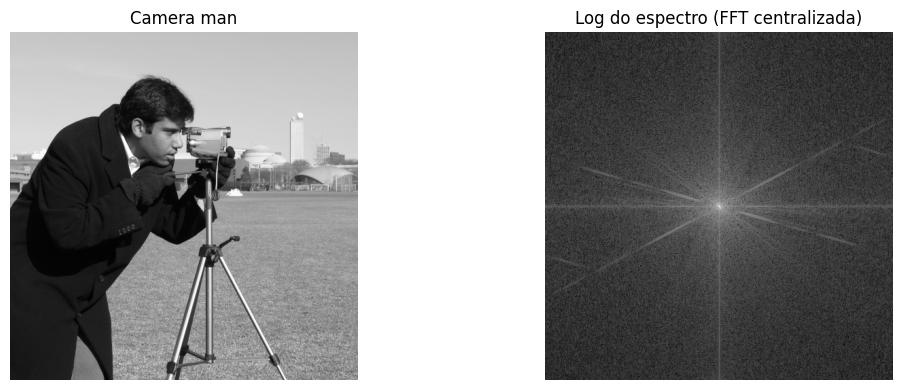

In [2]:
original = img_as_float(data.camera())

originalFFT, originalSpectrum = fft_spectrum(original)

show_images(
    [original, originalSpectrum],
    titles=["Camera man", "Log do espectro (FFT centralizada)"],
    cmap='gray',
    figsize=(12, 4)
)

### Criação das máscaras de filtragem

`radius` controla a frequência de corte.
- quanto menor o raio, mais forte e forte é o filtro passa-baixas (mais borramento)
- quanto maior o raio, mantêm-se mais detalhes.


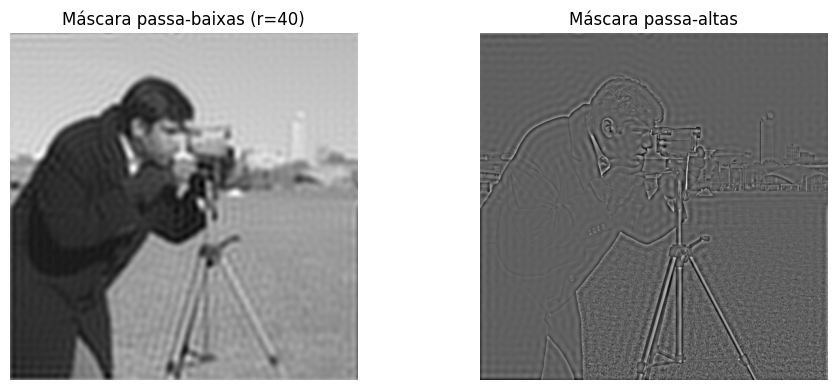

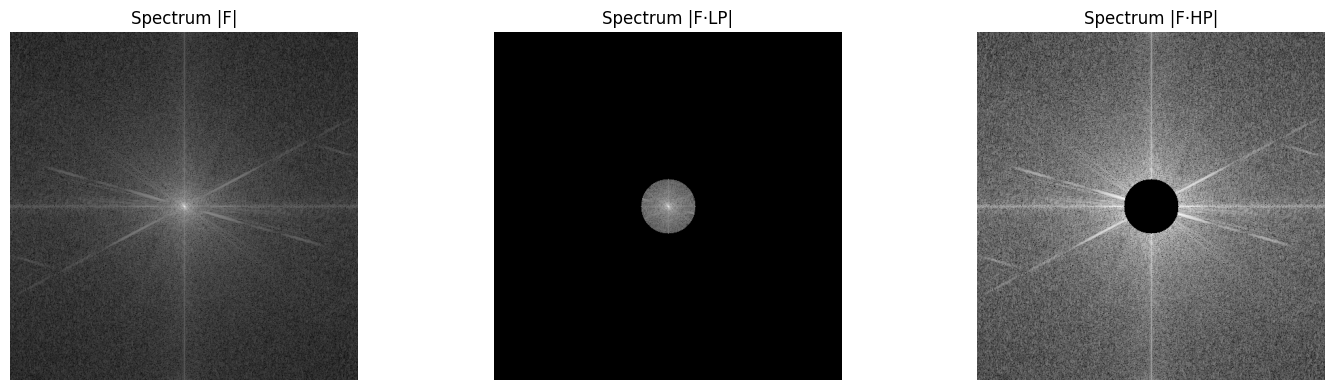

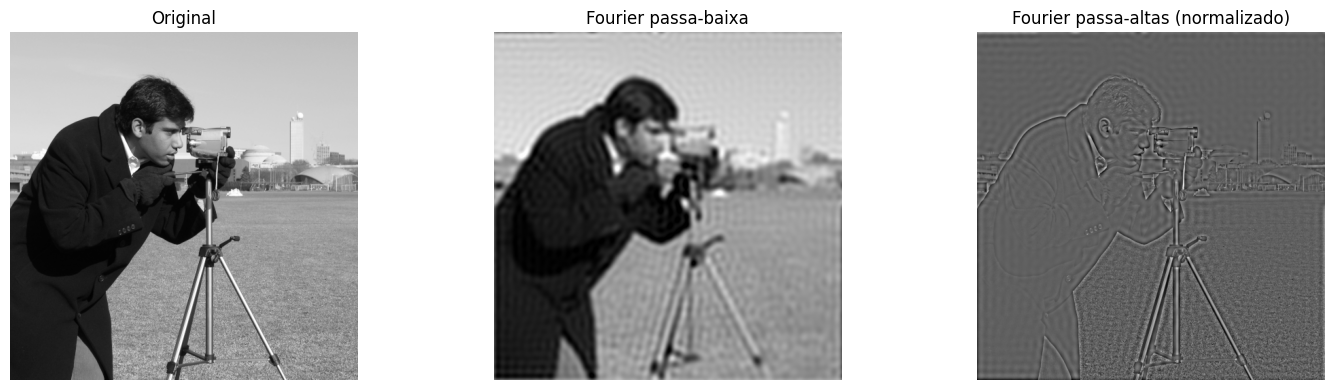

In [3]:
def lowpassMask(shape, radius):
    H, W = shape
    cy, cx = H // 2, W // 2
    Y, X = np.ogrid[:H, :W]
    dist = np.sqrt((Y - cy)**2 + (X - cx)**2)
    return (dist <= radius).astype(np.float64)

def applyFFT(img_gray, mask):
    F = np.fft.fft2(img_gray)
    Fshift = np.fft.fftshift(F)
    Gshift = Fshift * mask
    G = np.fft.ifftshift(Gshift)
    out = np.fft.ifft2(G)
    out = np.real(out)
    return out, Fshift, Gshift

radius = 40  # experimente com outros valores maiores

lpMask = lowpassMask(original.shape, radius=radius)
hpMask = 1.0 - lpMask

resImglp, Fshift, Glp = applyFFT(original, lpMask)
resImghp, _,   Ghp = applyFFT(original, hpMask)

# espectro para visualização
espectroF = np.log1p(np.abs(Fshift))
espectroGlp = np.log1p(np.abs(Glp))
espectroGhp = np.log1p(np.abs(Ghp))

show_images(
    [resImglp, resImghp],
    titles=[f"Máscara passa-baixas (r={radius})", "Máscara passa-altas"],
    cmap='gray',
    figsize=(10, 4)
)

show_images(
    [normalize01(espectroF), normalize01(espectroGlp), normalize01(espectroGhp)],
    titles=["Spectrum |F|", "Spectrum |F·LP|", "Spectrum |F·HP|"],
    cmap='gray',
    figsize=(15, 4)
)

show_images(
    [original, np.clip(resImglp, 0, 1), normalize01(resImghp)],
    titles=["Original", "Fourier passa-baixa", "Fourier passa-altas (normalizado)"],
    cmap='gray',
    figsize=(15, 4)
)


## Geração de padrões

Estes padrões são semelhantes aos apresentados na aula.

Experimente mudar os parâmetros e ver o que acontece com o espectro de Fourier


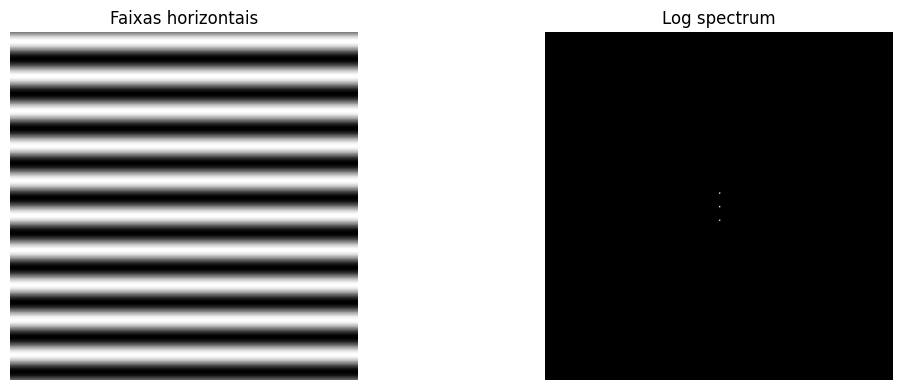

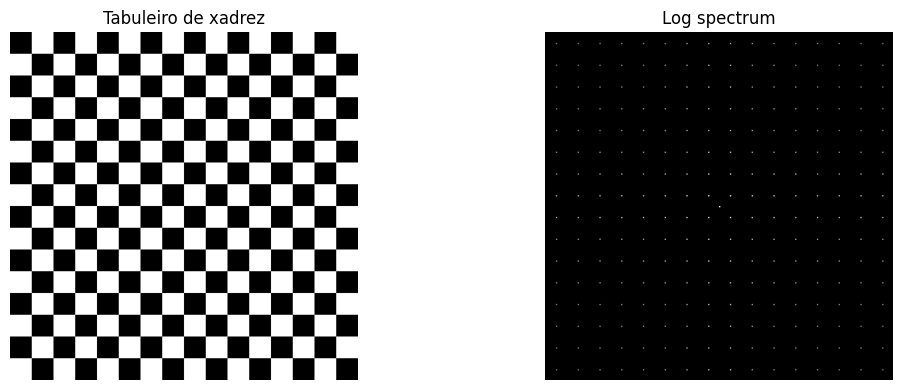

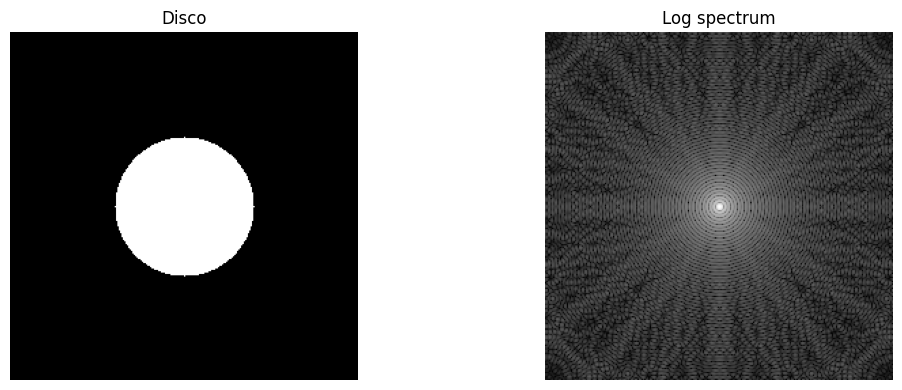

In [4]:
H, W = 256, 256
Y, X = np.mgrid[0:H, 0:W]

# faixas horizontal
freq = 10
stripes = 0.5 + 0.5 * np.sin(2*np.pi*freq*Y/H)

# tabuleiro de xadrez
check = ((X // 16) % 2) ^ ((Y // 16) % 2)
check = check.astype(np.float64)

# disco
cy, cx = H//2, W//2
disk = ((Y-cy)**2 + (X-cx)**2 <= (H//5)**2).astype(np.float64)

def show_img_and_spectrum(im, title):
    _, spec = fft_spectrum(im)
    show_images([im, spec], titles=[title, "Log spectrum"], cmap='gray', figsize=(12, 4))

show_img_and_spectrum(stripes, "Faixas horizontais")
show_img_and_spectrum(check, "Tabuleiro de xadrez")
show_img_and_spectrum(disk, "Disco")


## Exercícios extras

1. Fourier
   - Experimente mudar o raio e observar o compromisso entre raio das máscaras e observe o resultado da filtragem.
   - Experimente com máscaras que não estão centradas nas frequências baixas, como no exemplo do palhaço, apresentado em aula.

In [5]:
from google.colab import files
from skimage.io import imread
from skimage.color import rgb2gray
import numpy as np

# Upload dos arquivos
uploaded = files.upload()

imagens = []

for nome_arquivo in uploaded.keys():
    img = imread(nome_arquivo)

    # Converte para tons de cinza se estiver em RGB
    if len(img.shape) == 3:
        img = rgb2gray(img)

    imagens.append(img)

print(f"{len(imagens)} imagens carregadas com sucesso.")


Saving sandalia2_3.jpg to sandalia2_3.jpg
Saving sandalia2_2.jpg to sandalia2_2.jpg
Saving sandalia2_1.jpg to sandalia2_1.jpg
Saving sandalia1_3.jpg to sandalia1_3.jpg
Saving sandalia1_1.jpg to sandalia1_1.jpg
Saving sandalia1_2.jpg to sandalia1_2.jpg
Saving tenis1_1.jpg to tenis1_1.jpg
Saving tenis1_2.jpg to tenis1_2.jpg
Saving tenis1_3.jpg to tenis1_3.jpg
Saving tenis2_1.jpg to tenis2_1.jpg
Saving tenis2_2.jpg to tenis2_2.jpg
Saving tenis2_3.jpg to tenis2_3.jpg
12 imagens carregadas com sucesso.


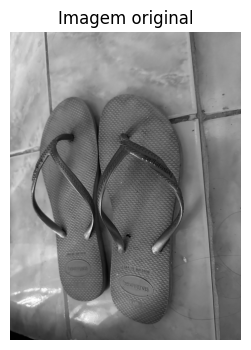

In [6]:
plt.figure(figsize=(4,4))
plt.imshow(imagens[0], cmap='gray')
plt.title("Imagem original")
plt.axis('off')
plt.show()


In [7]:
# Fourier 2D
img = imagens[0]

F = np.fft.fft2(img)
F_shift = np.fft.fftshift(F)
magnitude = np.log(1 + np.abs(F_shift))

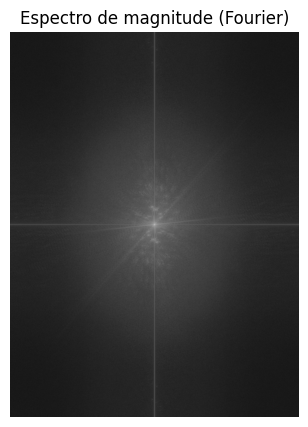

In [8]:
# espectro de Fourier
plt.figure(figsize=(5,5))
plt.imshow(magnitude, cmap='gray')
plt.title("Espectro de magnitude (Fourier)")
plt.axis('off')
plt.show()

In [9]:
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

raio = 30

# Máscara passa-baixa
mask_low = np.zeros((rows, cols), np.uint8)
cv, cu = np.ogrid[:rows, :cols]
dist = np.sqrt((cv - crow)**2 + (cu - ccol)**2)
mask_low[dist <= raio] = 1

# Máscara passa-alta
mask_high = 1 - mask_low

In [10]:
F_low = F_shift * mask_low
F_high = F_shift * mask_high

In [11]:
# domínio espacial (IFFT)
img_low = np.fft.ifft2(np.fft.ifftshift(F_low))
img_high = np.fft.ifft2(np.fft.ifftshift(F_high))

img_low = np.abs(img_low)
img_high = np.abs(img_high)

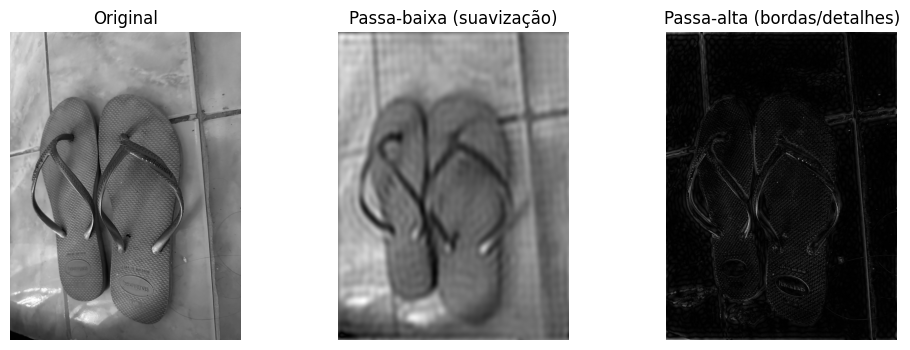

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_low, cmap='gray')
plt.title("Passa-baixa (suavização)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_high, cmap='gray')
plt.title("Passa-alta (bordas/detalhes)")
plt.axis('off')

plt.show()


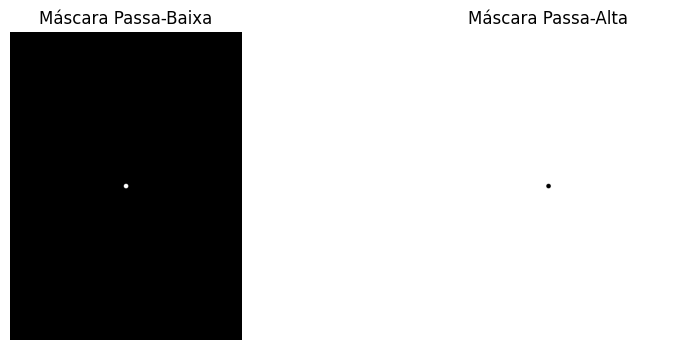

In [13]:
# máscaras no domínio da frequência
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask_low, cmap='gray')
plt.title("Máscara Passa-Baixa")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask_high, cmap='gray')
plt.title("Máscara Passa-Alta")
plt.axis('off')

plt.show()

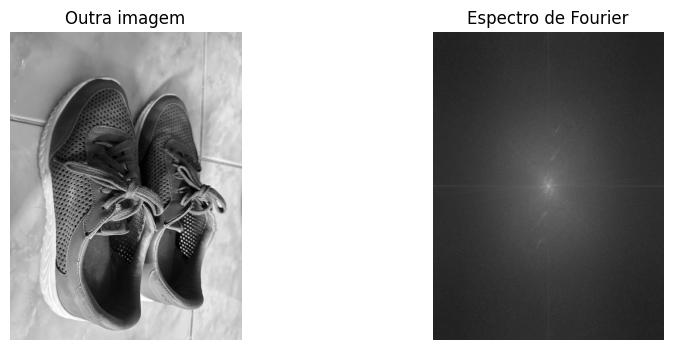

In [15]:
# tênis
img2 = imagens[8]

F2 = np.fft.fftshift(np.fft.fft2(img2))
mag2 = np.log(1 + np.abs(F2))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img2, cmap='gray')
plt.title("Outra imagem")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mag2, cmap='gray')
plt.title("Espectro de Fourier")
plt.axis('off')

plt.show()